# NB52 capacity parameter search — January 2026 start

Based on `52-opt-nb36-concentration-pool-breadth.ipynb`. This optimiser repeats the
NB52 concentration, pool-cap, and basket-breadth search, but trading starts on
2026-01-01 instead of 2025-08-01. All search values, selection, gating, sizing,
deposit-awareness, capacity assumptions, and the 2026-07-10 exclusive end date are
otherwise unchanged. Historical indicator lookback remains available before the
trading start.

## Key new insights and what did we learn from this experiment?

The 2026-only Calmar winner is a six-vault basket with a 45% concentration ceiling
and a 5% per-vault pool cap. It reaches 38.09% annualised CAGR with a -6.42% maximum
drawdown in the 189-day window. The closest alternative is six vaults / 50% / 5%
(36.64% CAGR, -6% grid-search drawdown); the 10-vault / 50% / 5% configuration has
the highest Sharpe among the leading candidates (1.95) and the shallowest drawdown
(-4%), but materially lower CAGR (22.55%).

The optimum is not stable enough to change the live default. Across the top 15
Calmar results, the 5% pool cap is the clearest preference (67% mode share), while
concentration has six distinct values and a weak 50% mode share of 27%; basket
breadth has four distinct values and an 8-vault mode share of 47%. The apparent
45% optimum should therefore be treated as a short-window candidate, not a precise
concentration estimate.

## Summary of results

The optimiser completed 18 Gaussian-process iterations (108 evaluated combinations),
with no failed or filtered backtests. The trading window is 2026-01-01 to 2026-07-09,
with 25,000 USD initial capital.

| Rank | Max assets | Max concentration | Pool cap | Calmar | CAGR | Sharpe | Grid max DD |
|---|---:|---:|---:|---:|---:|---:|---:|
| 1 | 6 | 45% | 5% | 6.33 | 38.09% | 1.84 | -6% |
| 2 | 6 | 50% | 5% | 6.17 | 36.64% | 1.83 | -6% |
| 3 | 10 | 50% | 5% | 5.75 | 22.55% | 1.95 | -4% |

The selected Calmar winner finishes at 29,546.73 USD: 18.19% cumulative return,
38.09% annualised CAGR, 1.84 Sharpe, 2.88 Sortino, and -6.42% maximum drawdown in
the performance report. It is invested 92% of the time, makes 809 trades across 73
closed or open strategy positions, and strongly outperforms BTC (-32.27%) and ETH
(-47.07%) over the same period.

## Robustness of results

- The portfolio-level PnL is spread across several vaults rather than one completed
  trade: Realist Capital contributes 2,273 USD across four positions, pmalt 1,623 USD
  across four, Scared Money 1,076 USD across eight, and Goon Edging 929 USD across
  six. The largest individual realised position is pmalt at 1,695 USD, 28% of the
  top-ten positive realised PnL. This is not a one-vault result.
- Nevertheless, daily-return sensitivity is severe. The best day is 2026-02-28 at
  +4.65%, versus BTC +1.67% and ETH +1.80% that day; it is outside the current
  curator quarantine windows. Daily excess kurtosis is 5.51, indicating elevated
  tail dependence rather than a known quarantined data spike.
- Neutralising the largest 5% of profitable days (five days above a 2.20% daily
  return) reduces cumulative return from 18.19% to 0.87%, annualised CAGR from
  38.09% to 1.69%, and Sharpe from 1.84 to 0.19; maximum drawdown deepens to
  -11.53%. This ex-post stress test leaves selections and trades unchanged.
- The seven-month 2026-only evaluation is both short and in-sample for the
  optimiser. It is useful for comparing capacity policy within this regime, but
  not sufficient evidence to replace the NB52/NB36 default settings without a
  separate holdout or walk-forward check.


## Notebook setup

- Shared imports, chart output settings, and notebook logging for the clean-up variant.

In [1]:
import datetime
import logging

import pandas as pd
import plotly.express as px
from IPython.display import display

from tradingstrategy.client import Client
from tradeexecutor.utils.notebook import setup_charting_and_output, OutputMode

client = Client.create_jupyter_client()
setup_charting_and_output(OutputMode.static, image_format='png', width=1500, height=1000)
logger = logging.getLogger('strategy')

Started Trading Strategy in Jupyter notebook environment, configuration is stored in /Users/moo/.tradingstrategy


## Universe definition

- Use the same Hyperliquid survivor-first vault universe as NB152 so the clean-up stays directly comparable.

In [2]:
from eth_defi.token import USDC_NATIVE_TOKEN
from tradingstrategy.chain import ChainId
from tradeexecutor.state.identifier import AssetIdentifier

CHAIN_ID = ChainId.hyperliquid

EXCHANGES = ('uniswap-v2', 'uniswap-v3')
SUPPORTING_PAIRS = [
    (ChainId.arbitrum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WBTC', 'USDC', 0.003),
]
LENDING_RESERVES = None
PREFERRED_STABLECOIN = AssetIdentifier(
    chain_id=ChainId.hyperliquid.value,
    address=USDC_NATIVE_TOKEN[ChainId.hyperliquid].lower(),
    token_symbol='USDC',
    decimals=6,
)
ALLOWED_VAULT_DENOMINATION_TOKENS = {'USDC', 'USDT', 'USDC.e', 'crvUSD', 'USDT0', 'USD₮0', 'USDt', 'USDS'}

print(f'Chain universe: {CHAIN_ID.get_name()}')
print(f'Reserve asset: {PREFERRED_STABLECOIN}')


Chain universe: HyperEVM
Reserve asset: <USDC at 0xb88339cb7199b77e23db6e890353e22632ba630f>


## Parameters

- Start from the validated NB36 release-candidate configuration.
- Search only `max_concentration_pct`, `per_position_cap_of_pool_pct`, and
  `max_assets_in_portfolio`.
- Use the categorical values from NB29, adding NB36's six-vault basket as the
  anchor configuration.


In [3]:
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.default_routing_options import TradeRouting
from tradeexecutor.strategy.parameters import StrategyParameters
from skopt.space import Categorical

from tradingstrategy.timebucket import TimeBucket


class Parameters:
    #: Notebook identifier.
    id = '54-opt-nb52-2026-start'

    #: Daily candles match the whole Hyperliquid survivor-first research chain.
    candle_time_bucket = TimeBucket.d1
    #: Daily rebalance cadence is the validated schedule used across the research chain.
    cycle_duration = CycleDuration.cycle_1d
    #: HyperEVM is the primary chain for vaults.
    chain_id = CHAIN_ID
    #: HyperEVM is the primary execution chain.
    primary_chain_id = CHAIN_ID
    #: Same exchange set as the release-candidate notebooks.
    exchanges = EXCHANGES

    #: Search the NB29 breadth grid with the NB36 six-vault anchor.

    max_assets_in_portfolio = Categorical([5, 6, 8, 10, 15, 20])
    #: 98% target deployment, the validated release default.
    allocation_pct = 0.98
    #: Search the prior concentration grid. Tight values may deliberately
    #: sacrifice deployment when the eligible basket is thin.

    max_concentration_pct = Categorical([0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50])
    #: Search the prior per-vault TVL capacity grid.

    per_position_cap_of_pool_pct = Categorical([0.05, 0.10, 0.15, 0.20])
    #: Engine hygiene threshold for cleaning up tiny residual positions.
    min_portfolio_weight_pct = 0.005

    #: Hyperliquid has a hard 5 USD minimum deposit.
    absolute_min_vault_deposit_usd = 5.0
    #: Buy threshold as a fraction of initial cash.
    individual_rebalance_min_threshold_of_initial_cash_pct = 0.0005
    #: Sell threshold as a fraction of initial cash.
    sell_rebalance_min_threshold_of_initial_cash_pct = 0.0001

    #: Survivor-first TVL floor selected in NB141.
    min_tvl_usd = 7_500

    #: Trailing window (days) for the CAGR leg of the composite selection score.
    cagr_lookback_days = 360
    #: Trailing window (days) for the Sharpe leg of the composite selection score.
    sharpe_lookback_days = 180
    #: Composite blend: ``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score``.
    #: NB31 showed both legs are load-bearing: either leg alone is materially worse on
    #: both CAGR and drawdown.
    cagr_weight = 0.50
    #: Momentum gate window: a vault is eligible only while its trailing return over
    #: this window exceeds :py:attr:`gate_threshold`. NB31: pure drawdown insurance at
    #: zero return cost (removal: -4.5pp CAGR and max DD -7.4% -> -17.5%).
    gate_lookback_days = 14
    #: Momentum gate threshold (fraction).
    gate_threshold = -0.08
    #: Rolling window for the inverse-volatility sizing weight. NB31: the single
    #: biggest contributor - equal weight halves CAGR and triples drawdown.
    inverse_vol_window = 60

    #: Start trading from January 2026 while retaining pre-start indicator history.
    backtest_start = datetime.datetime(2026, 1, 1)
    #: Exclusive end boundary.
    backtest_end = datetime.datetime(2026, 7, 10)
    #: Release-candidate bankroll.
    initial_cash = 25_000
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    individual_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * individual_rebalance_min_threshold_of_initial_cash_pct,
    )
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    sell_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * sell_rebalance_min_threshold_of_initial_cash_pct,
    )

    #: Optimiser runs do not model managed yield.
    use_managed_yield = False

    #: Default routing is still required by the strategy runtime even though it is not the alpha source.
    routing = TradeRouting.default
    #: Set deliberately high so live and notebook indicator calculations use effectively
    #: all available history; history-derived indicators would be silently biased by a
    #: truncated lookback window.
    required_history_period = datetime.timedelta(days=365 * 20)
    #: Same live-style slippage assumption as the release-candidate notebooks.
    slippage_tolerance_pct = 0.0060
    #: Assume no liquidity if there is a gap in TVL data.
    assummed_liquidity_when_data_missings_usd = 0.01


parameters = StrategyParameters.from_class(Parameters)

from tradeexecutor.strategy.parameters import display_parameters

display_parameters(parameters)


,Value,Type
Name,,
absolute_min_vault_deposit_usd,5.0,float
allocation_pct,0.98,float
assummed_liquidity_when_data_missings_usd,0.01,float
backtest_end,2026-07-10 00:00:00,datetime
backtest_start,2026-01-01 00:00:00,datetime
cagr_lookback_days,360,int
cagr_weight,0.5,float
candle_time_bucket,TimeBucket.d1,TimeBucket
chain_id,999,ChainId


## Trading universe

- Build the tradable supporting-pair and Hyperliquid vault universe used by the backtest.

In [4]:
from dotenv import load_dotenv
from tradingstrategy.utils.token_filter import filter_for_selected_pairs
from tradeexecutor.analysis.pair import display_strategy_universe
from tradeexecutor.strategy.execution_context import notebook_execution_context
from tradeexecutor.strategy.pandas_trader.trading_universe_input import CreateTradingUniverseInput
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse, load_partial_data, load_vault_universe_with_metadata
from tradeexecutor.strategy.universe_model import UniverseOptions
from tradeexecutor.utils.notebook import display_dataframe_with_html, display_head_and_tail

from tradeexecutor.curator import build_hyperliquid_vault_universe

load_dotenv(override=True)


def create_trading_universe(
    input: CreateTradingUniverseInput,
) -> TradingStrategyUniverse:
    """Create the release-candidate trading universe.

    Keep the backtest trading window fixed to `Parameters.backtest_start` /
    `Parameters.backtest_end`, but let `required_history_period` extend the
    data-loading window backwards so age and other history-derived indicators
    can see the full pre-backtest history for the selected vaults.
    """
    execution_context = input.execution_context
    client = input.client
    timestamp = input.timestamp
    parameters = input.parameters or Parameters
    universe_options = input.universe_options

    debug_printer = logger.info if execution_context.live_trading else print

    chain_id = parameters.primary_chain_id
    debug_printer(f'Preparing trading universe on chain {chain_id.get_name()}')

    all_pairs_df = client.fetch_pair_universe().to_pandas()
    pairs_df = filter_for_selected_pairs(all_pairs_df, SUPPORTING_PAIRS)
    debug_printer(f'We have total {len(all_pairs_df)} pairs in dataset and going to use {len(pairs_df)} pairs for the strategy')

    # Full, non-survivorship-biased universe: `top_n=None` still applies the
    # 120-vault CAGR cap baked into `CHAIN_CONFIG[9999]["top_n"]`, so pass an
    # explicit oversized `top_n` to keep every eligible Hyperliquid vault.
    source_vaults = build_hyperliquid_vault_universe(
        min_tvl=parameters.min_tvl_usd,
        min_age=0.0,
        top_n=9999,
    )
    vault_universe = load_vault_universe_with_metadata(client, vaults=source_vaults)
    vault_universe = vault_universe.limit_to_denomination(ALLOWED_VAULT_DENOMINATION_TOKENS, check_all_vaults_found=True)
    debug_printer(f'Loaded {vault_universe.get_vault_count()} vaults from remote vault metadata, source vaults count: {len(source_vaults)}')

    # `load_partial_data()` now honours `required_history_period` in backtests
    # as a loader-window extension instead of clipping history to the trading window.
    dataset = load_partial_data(
        client=client,
        time_bucket=parameters.candle_time_bucket,
        pairs=pairs_df,
        execution_context=execution_context,
        universe_options=universe_options,
        liquidity=True,
        liquidity_time_bucket=TimeBucket.d1,
        lending_reserves=LENDING_RESERVES,
        vaults=vault_universe,
        vault_history_source="trading-strategy-website",
        check_all_vaults_found=True,
    )

    return TradingStrategyUniverse.create_from_dataset(
        dataset,
        reserve_asset=PREFERRED_STABLECOIN,
        forward_fill=True,
        forward_fill_until=timestamp,
        primary_chain=parameters.primary_chain_id,
    )


universe_input = CreateTradingUniverseInput(
    execution_context=notebook_execution_context,
    client=client,
    timestamp=None,
    parameters=parameters,
    universe_options=UniverseOptions.from_strategy_parameters_class(Parameters, notebook_execution_context),
    execution_model=None,
)

strategy_universe = create_trading_universe(universe_input)
df = display_strategy_universe(
    strategy_universe,
    sort_key='base',
    sort_numeric=False,
    limit=75,
    show_token_risk=True,
    show_tokensniffer=True,
)
display_head_and_tail(df, head_rows=5, tail_rows=5)


Preparing trading universe on chain HyperEVM


We have total 392231 pairs in dataset and going to use 3 pairs for the strategy
Hypercore universe fingerprint: 7aa6c710
Loaded 326 cached Hypercore vaults (tvl7500-top9999-age0.0-sort1Y-cur7aa6c710)


Failed to parse vault entry: 4217 is not a valid ChainId


Failed to parse vault entry: 4217 is not a valid ChainId


Failed to parse vault entry: 4217 is not a valid ChainId


...

Loading TVL/liquidity data for 3 pairs: 100%|██████████| 3/3 [00:01<00:00,  1.87it/s]

Results limited to first 75 entries
Head (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
278548699,Sistema I,USDC,hyperliquid,traded,NaN,0.72,2025-12-10 00:00:00,18 days 00:00:00,0.00,"12,784",17 days,- / -,None,None,-,10.0%,0.0%
282757120,$NIKEPIG's,USDC,hyperliquid,traded,NaN,0.65,2026-01-14 00:00:00,18 days 00:00:00,0.00,"28,035",17 days,- / -,None,None,-,10.0%,0.0%
268714989,$🏧| ATM |🏧,USDC,hyperliquid,traded,NaN,,-,-,0.00,292,17 days,- / -,None,None,-,10.0%,0.0%
284367427,-VectorZer,USDC,hyperliquid,traded,NaN,1.95,2025-01-01 00:00:00,18 days 00:00:00,0.00,"65,250",17 days,- / -,None,None,-,10.0%,0.0%
269753871,0xBTC脉冲,USDC,hyperliquid,traded,NaN,0.99,2026-01-21 00:00:00,18 days 00:00:00,0.00,"31,126",17 days,- / -,None,None,-,10.0%,0.0%


Tail (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
269605231,Crypto Cza,USDC,hyperliquid,traded,NaN,0.40,2026-02-09 00:00:00,18 days 00:00:00,0.00,107,17 days,- / -,None,None,-,10.0%,0.0%
273445636,Crypto Pla,USDC,hyperliquid,traded,NaN,0.76,2025-05-28 00:00:00,18 days 00:00:00,0.00,"14,927",17 days,- / -,None,None,-,10.0%,0.0%
284307624,Crypto Tra,USDC,hyperliquid,traded,NaN,1.26,2024-12-04 00:00:00,18 days 00:00:00,0.00,"150,636",17 days,- / -,None,None,-,10.0%,0.0%
271831735,CryptoZer0,USDC,hyperliquid,traded,NaN,3.67,2023-05-10 00:00:00,18 days 00:00:00,0.00,579,17 days,- / -,None,None,-,10.0%,0.0%
276885198,Cycle Mode,USDC,hyperliquid,traded,NaN,0.40,2025-11-19 00:00:00,18 days 00:00:00,0.00,"7,422",17 days,- / -,None,None,-,10.0%,0.0%


## Indicators

- Define the same inclusion and `age_ramp` indicators used by the parent notebook.

In [5]:
from tradeexecutor.state.identifier import TradingPairIdentifier
from tradeexecutor.state.types import USDollarAmount
from tradeexecutor.strategy.execution_context import ExecutionContext
from tradeexecutor.strategy.pandas_trader.indicator import IndicatorDependencyResolver, IndicatorSource
from tradeexecutor.strategy.pandas_trader.indicator_decorator import IndicatorRegistry
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse
from tradeexecutor.analysis.indicator import display_indicators

indicators = IndicatorRegistry()


@indicators.define(source=IndicatorSource.tvl)
def tvl(
    close: pd.Series,
    execution_context: ExecutionContext,
    timestamp: pd.Timestamp,
) -> pd.Series:
    if execution_context.live_trading:
        from tradingstrategy.utils.forward_fill import forward_fill

        df = pd.DataFrame({'close': close})
        df_ff = forward_fill(
            df,
            Parameters.candle_time_bucket.to_frequency(),
            columns=('close',),
            forward_fill_until=timestamp,
        )
        return df_ff['close']

    return close.resample('1h').ffill()


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_universe)
def tvl_inclusion_criteria(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(tvl)
    mask = series >= min_tvl_usd
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_availability_criteria(
    strategy_universe: TradingStrategyUniverse,
) -> pd.Series:
    candle_series = strategy_universe.data_universe.candles.df['open']
    return candle_series.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(
    dependencies=[
        tvl_inclusion_criteria,
        trading_availability_criteria,
    ],
    source=IndicatorSource.strategy_universe,
)
def inclusion_criteria(
    strategy_universe: TradingStrategyUniverse,
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    benchmark_pair_ids = {
        strategy_universe.get_pair_by_human_description(desc).internal_id
        for desc in SUPPORTING_PAIRS
    }

    tvl_series = dependency_resolver.get_indicator_data(
        tvl_inclusion_criteria,
        parameters={'min_tvl_usd': min_tvl_usd},
    )
    trading_availability_series = dependency_resolver.get_indicator_data(trading_availability_criteria)

    df = pd.DataFrame(
        {
            'tvl_pair_ids': tvl_series,
            'trading_availability_pair_ids': trading_availability_series,
        }
    )
    df = df.fillna('').apply(list)

    def _combine(row):
        final_set = set(row['tvl_pair_ids']) & set(row['trading_availability_pair_ids'])
        return final_set - benchmark_pair_ids

    union_criteria = df.apply(_combine, axis=1)
    full_index = pd.date_range(
        start=union_criteria.index.min(),
        end=union_criteria.index.max(),
        freq=Parameters.candle_time_bucket.to_frequency(),
    )
    return union_criteria.reindex(full_index, fill_value=[])


#: CAGR of +100% (1.0) or more earns the full CAGR sub-score of 1.0.
CAGR_SCORE_CAP = 1.0
#: Annualised Sharpe of 3.0 or more earns the full Sharpe sub-score of 1.0.
SHARPE_SCORE_CAP = 3.0
#: Daily-return annualisation factor for the rolling Sharpe score.
TRADING_DAYS_PER_YEAR = 365.0


@indicators.define()
def cagr_score(close: pd.Series, cagr_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-CAGR sub-score in ``[0, 1]``.

    Annualise the vault share-price return over the trailing
    ``cagr_lookback_days`` window and map ``0..100%`` CAGR linearly to
    ``0..1``, clipping negative CAGR to ``0`` and CAGR above ``+100%`` to ``1``.
    Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(cagr_lookback_days)
    ratio = close / close.shift(lookback)
    cagr = ratio.pow(TRADING_DAYS_PER_YEAR / lookback) - 1.0
    return (cagr / CAGR_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define()
def sharpe_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sharpe sub-score in ``[0, 1]``.

    Compute the annualised Sharpe ratio of daily share-price returns over the
    trailing ``sharpe_lookback_days`` window and map ``0..3.0`` Sharpe linearly
    to ``0..1``, clipping negative Sharpe to ``0`` and Sharpe above ``3.0`` to
    ``1``. Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(sharpe_lookback_days)
    daily_returns = close.pct_change()
    rolling_mean = daily_returns.rolling(lookback, min_periods=lookback).mean()
    rolling_std = daily_returns.rolling(lookback, min_periods=lookback).std()
    sharpe = (rolling_mean / rolling_std.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sharpe / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sharpe_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sharpe_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score`` composite.

    Both sub-scores are already bounded to ``[0, 1]`` so the blend is also in
    ``[0, 1]`` for any ``cagr_weight`` in ``[0, 1]``. A vault must have enough
    history to compute *both* sub-scores for the timestamp (i.e.
    ``max(cagr_lookback_days, sharpe_lookback_days)`` days); otherwise the
    composite is ``NaN`` and the decision function treats the vault as an
    unscored, lowest-priority candidate.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score", pair=pair, parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sharpe_component = dependency_resolver.get_indicator_data(
        "sharpe_score", pair=pair, parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sharpe_component


#: Floor on daily volatility so inverse-vol cannot explode for near-flat series.
VOL_FLOOR = 1e-4


@indicators.define()
def inverse_vol(close: pd.Series, inverse_vol_window: int = 60) -> pd.Series:
    """Inverse rolling daily-return volatility (higher = calmer); NaN below the window."""
    lb = int(inverse_vol_window)
    vol = close.pct_change().rolling(lb, min_periods=lb).std()
    return 1.0 / vol.clip(lower=VOL_FLOOR)


@indicators.define()
def return_gate(close: pd.Series, gate_lookback_days: int = 30) -> pd.Series:
    """Raw trailing return over `gate_lookback_days` used as the eligibility gate; NaN below window."""
    lb = int(gate_lookback_days)
    return close / close.shift(lb) - 1.0


@indicators.define(dependencies=(tvl_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def tvl_included_pair_count(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "tvl_inclusion_criteria",
        parameters={
            "min_tvl_usd": min_tvl_usd,
        },
    )
    return series.apply(len)


display_indicators(indicators)


We have 10 indicators:


,Order,Source,Parameters,Dependencies
Name,,,,
cagr_score,1,close_price,cagr_lookback_days,
inverse_vol,1,close_price,inverse_vol_window,
return_gate,1,close_price,gate_lookback_days,
sharpe_score,1,close_price,sharpe_lookback_days,
trading_availability_criteria,1,strategy_universe,,
tvl,1,tvl,,
cagr_sharpe_weight,2,dependencies_only_per_pair,cagr_weight<br> sharpe_lookback_days<br> cagr_...,cagr_score<br> sharpe_score
tvl_inclusion_criteria,2,dependencies_only_universe,min_tvl_usd,tvl
inclusion_criteria,3,strategy_universe,min_tvl_usd,tvl_inclusion_criteria<br> trading_availabilit...


# Time range for backtest

In [6]:
backtest_start = Parameters.backtest_start
backtest_end = Parameters.backtest_end
print(f'Time range is {backtest_start} - {backtest_end}')

Time range is 2026-01-01 00:00:00 - 2026-07-10 00:00:00


# Algorithm

Composite selection -> momentum gate -> inverse-volatility weighting (the NB29 #48 configuration).

In [7]:
from tradeexecutor.exchange_account.allocation import (
    calculate_portfolio_target_value,
    get_redeemable_portfolio_capital,
)
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.strategy.alpha_model import AlphaModel
from tradeexecutor.strategy.execution_context import ExecutionMode
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput
from tradeexecutor.strategy.tvl_size_risk import USDTVLSizeRiskModel
from tradeexecutor.strategy.weighting import weight_passthrouh
from tradeexecutor.utils.dedent import dedent_any
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.curator import is_quarantined


def decide_trades(input: StrategyInput) -> list[TradeExecution]:
    # Rank by the CAGR+Sharpe composite, gate on trailing momentum, size by inverse volatility.
    parameters = input.parameters
    max_assets_in_portfolio = int(parameters.max_assets_in_portfolio)
    position_manager = input.get_position_manager()
    state = input.state
    timestamp = input.timestamp
    indicators = input.indicators
    strategy_universe = input.strategy_universe

    portfolio = position_manager.get_current_portfolio()
    equity = portfolio.get_total_equity()
    if input.execution_context.mode == ExecutionMode.backtesting and equity < parameters.initial_cash * 0.10:
        return []

    tvl_included_pair_count = indicators.get_indicator_value('tvl_included_pair_count')
    included_pairs = indicators.get_indicator_value('inclusion_criteria', na_conversion=False)
    included_pairs = [] if included_pairs is None else list(included_pairs)
    candidates = []
    weight_by_id = {}
    gate_threshold = float(parameters.gate_threshold)
    for pair_id in included_pairs:
        pair = strategy_universe.get_pair_by_id(pair_id)
        if not state.is_good_pair(pair) or is_quarantined(pair.pool_address, timestamp):
            continue
        # Momentum gate: drop (and therefore sell) any vault whose trailing return is at or
        # below the threshold, so decliners leave the basket instead of being held.
        gate_value = indicators.get_indicator_value('return_gate', pair=pair)
        if gate_value is None or gate_value != gate_value or gate_value <= gate_threshold:
            continue
        composite_signal = indicators.get_indicator_value('cagr_sharpe_weight', pair=pair)
        signal = float(composite_signal) if composite_signal is not None and composite_signal == composite_signal else 0.0
        inv_vol = indicators.get_indicator_value('inverse_vol', pair=pair)
        weight_by_id[pair_id] = float(inv_vol) if inv_vol is not None and inv_vol == inv_vol else 0.0
        candidates.append((pair_id, pair, signal))
    if not candidates:
        return []

    # Rank by composite (selection), but SIZE by inverse volatility (linear weighting).
    ordered = sorted(candidates, key=lambda item: (-item[2], item[0]))

    # Vault-closed awareness: walk the ranking and give basket slots only to vaults that
    # can take new deposits. A vault we already hold keeps its slot even with a closed
    # deposit window - closed deposits block new capital, not holding, and the sell side
    # remains governed by the momentum gate. The check is lazy so live execution makes
    # only a handful of `vaultDetails` API calls per cycle.
    held_pair_ids = {
        position.pair.internal_id
        for position in state.portfolio.get_open_positions()
        if not position.pair.is_credit_supply()
    }
    selected = []
    deposit_window_skips = 0
    for candidate in ordered:
        if len(selected) >= max_assets_in_portfolio:
            break
        pair_id, pair, signal = candidate
        if pair_id not in held_pair_ids and not input.pricing_model.can_deposit(timestamp, pair):
            deposit_window_skips += 1
            continue
        selected.append(candidate)

    alpha_model = AlphaModel(
        timestamp,
        close_position_weight_epsilon=parameters.min_portfolio_weight_pct,
    )
    for pair_id, pair, signal in selected:
        alpha_model.set_signal(pair, weight_by_id.get(pair_id, 0.0))
    alpha_model.select_top_signals(count=len(selected))
    alpha_model.assign_weights(method=weight_passthrouh)

    redeemable_capital = get_redeemable_portfolio_capital(position_manager)
    portfolio_target_value = calculate_portfolio_target_value(position_manager, parameters.allocation_pct)
    size_risk_model = USDTVLSizeRiskModel(
        pricing_model=input.pricing_model,
        per_position_cap=float(parameters.per_position_cap_of_pool_pct),
    )
    alpha_model.normalise_weights(
        investable_equity=portfolio_target_value,
        size_risk_model=size_risk_model,
        max_weight=float(parameters.max_concentration_pct),
        max_positions=max_assets_in_portfolio,
        waterfall=False,
    )
    alpha_model.update_old_weights(state.portfolio, ignore_credit=False)
    alpha_model.calculate_target_positions(position_manager)
    trades = alpha_model.generate_rebalance_trades_and_triggers(
        position_manager,
        min_trade_threshold=parameters.individual_rebalance_min_threshold_usd,
        individual_rebalance_min_threshold=parameters.individual_rebalance_min_threshold_usd,
        sell_rebalance_min_threshold=parameters.sell_rebalance_min_threshold_usd,
        execution_context=input.execution_context,
    )
    state.visualisation.add_calculations(timestamp, {'unallocatable_signals': alpha_model.get_unallocatable_signals()})

    if input.is_visualisation_enabled():
        try:
            top_signal = next(iter(alpha_model.get_signals_sorted_by_weight()))
            if top_signal.normalised_weight == 0:
                top_signal = None
        except StopIteration:
            top_signal = None

        rebalance_volume = sum(trade.get_value() for trade in trades)
        report = dedent_any(f'''
            Cycle: #{input.cycle}
            Rebalanced: {'👍' if alpha_model.is_rebalance_triggered() else '👎'}
            Open/about to open positions: {len(state.portfolio.open_positions)}
            Max position value change: {alpha_model.max_position_adjust_usd:,.2f} USD
            Rebalance threshold: {alpha_model.position_adjust_threshold_usd:,.2f} USD
            Trades decided: {len(trades)}
            Pairs meeting inclusion criteria: {len(included_pairs)}
            Pairs meeting TVL inclusion criteria: {tvl_included_pair_count}
            Candidate signals created: {len(candidates)}
            Selected survivor signals: {len(alpha_model.signals)}
            Candidates skipped for closed deposit window: {deposit_window_skips}
            CAGR lookback days: {parameters.cagr_lookback_days}
            Sharpe lookback days: {parameters.sharpe_lookback_days}
            CAGR weight (blend): {parameters.cagr_weight}
            Total equity: {portfolio.get_total_equity():,.2f} USD
            Cash: {position_manager.get_current_cash():,.2f} USD
            Redeemable capital: {redeemable_capital:,.2f} USD
            Pending redemptions: {position_manager.get_pending_redemptions():,.2f} USD
            Investable equity: {alpha_model.investable_equity:,.2f} USD
            Accepted investable equity: {alpha_model.accepted_investable_equity:,.2f} USD
            Allocated to signals: {alpha_model.get_allocated_value():,.2f} USD
            Discarded allocation because of lack of lit liquidity: {alpha_model.size_risk_discarded_value:,.2f} USD
            Rebalance volume: {rebalance_volume:,.2f} USD
            ''')
        if top_signal:
            assert top_signal.position_size_risk
            report += dedent_any(f'''
                Top signal pair: {top_signal.pair.get_ticker()}
                Top signal value: {top_signal.signal}
                Top signal weight: {top_signal.raw_weight}
                Top signal weight (normalised): {top_signal.normalised_weight * 100:.2f} % (got {top_signal.position_size_risk.get_relative_capped_amount() * 100:.2f} % of asked size)
                ''')
        for flag, count in alpha_model.get_flag_diagnostics_data().items():
            report += f'Signals with flag {flag.name}: {count}' + '\n'
        state.visualisation.add_message(timestamp, report)
        state.visualisation.set_discardable_data('alpha_model', alpha_model)

    return trades


# Optimiser

- Run optimiser

In [8]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="The 'generic' unit for NumPy timedelta is deprecated.*",
    category=DeprecationWarning,
)

import logging
from tradeexecutor.backtest.optimiser import perform_optimisation
from tradeexecutor.backtest.optimiser import prepare_optimiser_parameters
from tradeexecutor.backtest.optimiser import MinTradeCountFilter
from tradeexecutor.backtest.optimiser_functions import optimise_sharpe, optimise_calmar

# How many Gaussian Process iterations we do
iterations = 18

# What do we optimise for
# Tune the gate for drawdown control: Calmar = CAGR / |max drawdown|.
search_func = optimise_calmar
# search_func = optimise_sharpe

optimiser_result = perform_optimisation(
    iterations=iterations,
    search_func=search_func,
    decide_trades=decide_trades,
    strategy_universe=strategy_universe,
    parameters=prepare_optimiser_parameters(Parameters),  # Handle scikit-optimise search space
    create_indicators=indicators.create_indicators,
    result_filter=MinTradeCountFilter(50),
    timeout=70*60,    
    batch_size=6,
    # We are searching wacky parameter combinations and
    # some of them lead to buggy strategies,
    # by setting ignore_wallet_errors we just zero out buggy
    # strategies instead of crashing with an exception
    ignore_wallet_errors=True,  
    # Uncomment for diagnostics
    # log_level=logging.INFO,
    # max_workers=1,
)

print(f"Optimise completed, optimiser searched {optimiser_result.get_combination_count()} combinations, with {optimiser_result.get_cached_count()} results read directly from cache. and {optimiser_result.get_filtered_count()} filtered results.")
print("Backtests failed with exception:", optimiser_result.get_failed_count())

Optimiser search result cache is /Users/moo/.cache/tradingstrategy/grid-search/54-opt-nb52-2026-start
Indicator cache is /Users/moo/.cache/indicators


Optimise completed, optimiser searched 108 combinations, with 108 results read directly from cache. and 0 filtered results.
Backtests failed with exception: 0


# Results

- Show the top results of all optimiser iterations in a single table

In [9]:
from tradeexecutor.analysis.optimiser import analyse_optimiser_result
from tradeexecutor.analysis.grid_search import render_grid_search_result_table


filtered = [r for r in optimiser_result.results if r.filtered]
print(f"Filtering out {len(filtered)} results")

# Optimiser already filtered for min_positions_threshold when doing the optimiser run
df = analyse_optimiser_result(
    optimiser_result,
    max_search_results=300,
    drop_duplicates=False,
)
print(f"Showing the best {len(df)} results")

# Put concentration first and sort the rendered result table by it.
# Keep `df` unchanged for the downstream parameter analyses.
display_df = df.reorder_levels([
    'max_concentration_pct',
    'max_assets_in_portfolio',
    'per_position_cap_of_pool_pct',
]).sort_index(level='max_concentration_pct')

render_grid_search_result_table(display_df)
 

Filtering out 0 results
Showing the best 108 results


## Search stability check

Do the top configurations agree on their parameters, and how tight is the Calmar plateau? Read alongside the heatmaps, cluster analysis and parallel-coordinates plots below.

In [10]:
# Numeric stability: parameter consensus across the top-Calmar configs.
stab = df.reset_index().copy()
if 'Calmar' not in stab.columns:
    stab['Calmar'] = stab['CAGR'] / stab['Max DD'].abs().replace(0, float('nan'))
stab = stab.sort_values('Calmar', ascending=False)
param_cols = list(df.index.names)
TOPN = 15
top = stab.head(TOPN)

print(f"Parameter consensus across the top {TOPN} configs by Calmar:")
rows = []
for pc in param_cols:
    vc = top[pc].value_counts(normalize=True)
    rows.append({'parameter': pc, 'mode': vc.index[0], 'mode_share': round(float(vc.iloc[0]), 2), 'distinct_in_top': int(top[pc].nunique())})
display(pd.DataFrame(rows))

print(f"Calmar in top {TOPN}: {top['Calmar'].min():.2f} - {top['Calmar'].max():.2f}   (all {len(stab)}: {stab['Calmar'].min():.2f} - {stab['Calmar'].max():.2f})")
print("A high mode_share (parameter agrees across the best configs) = stable; low share = the optimum is not well-determined on that axis.")


Parameter consensus across the top 15 configs by Calmar:


,parameter,mode,mode_share,distinct_in_top
0,max_assets_in_portfolio,8.00,0.47,4
1,max_concentration_pct,0.50,0.27,6
2,per_position_cap_of_pool_pct,0.05,0.67,3


Calmar in top 15: 4.07 - 6.35   (all 108: -0.41 - 6.35)
A high mode_share (parameter agrees across the best configs) = stable; low share = the optimum is not well-determined on that axis.


## Equity curves

- Visualise equity curves of all grid search results in a single chart

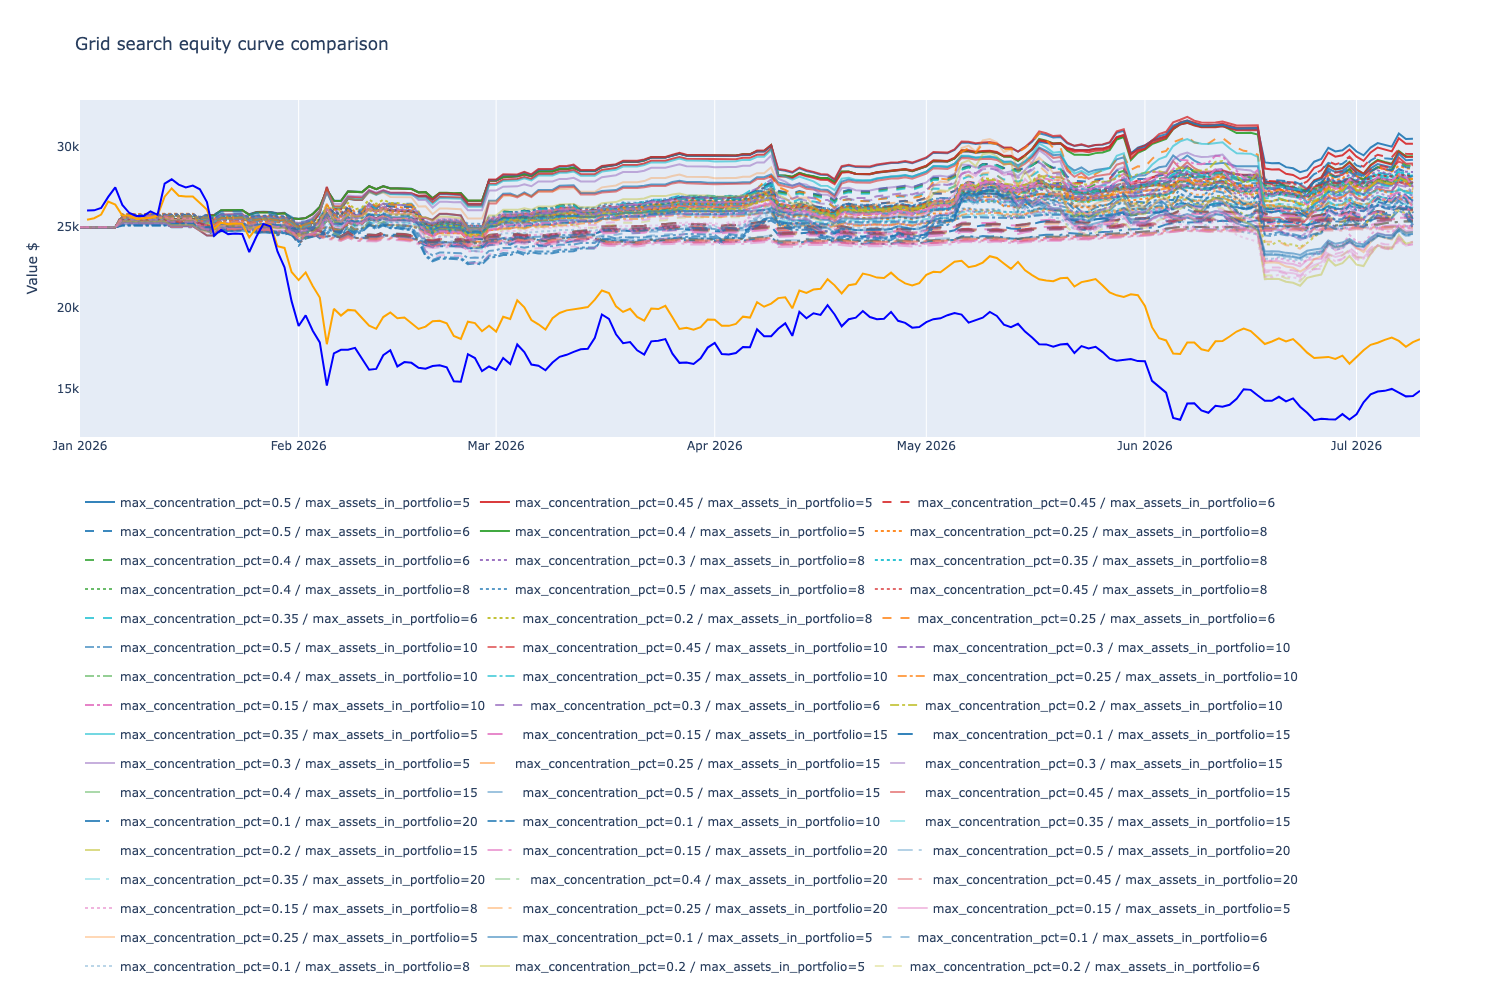

In [11]:
from tradeexecutor.visual.grid_search_basic import visualise_grid_search_equity_curves
from tradeexecutor.analysis.multi_asset_benchmark import get_benchmark_data

# Automatically create BTC and ETH buy and hold benchmark if present
# in the trading universe
benchmark_indexes = get_benchmark_data(
    strategy_universe,
    cumulative_with_initial_cash=Parameters.initial_cash,
    start_at=pd.Timestamp(Parameters.backtest_start),
)

# Extract GridSearchResult instances from optimiser results
grid_search_results = [r.result for r in optimiser_result.results if not r.filtered]

fig = visualise_grid_search_equity_curves(
    grid_search_results,
    benchmark_indexes=benchmark_indexes,
    log_y=False,
    group_by="max_concentration_pct",
    group_by_secondary="max_assets_in_portfolio",
)
fig.show()

# Parameter analysis

## Decision tree visualisation

Analysing Calmar for parameters: ['max_assets_in_portfolio', 'max_concentration_pct', 'per_position_cap_of_pool_pct']


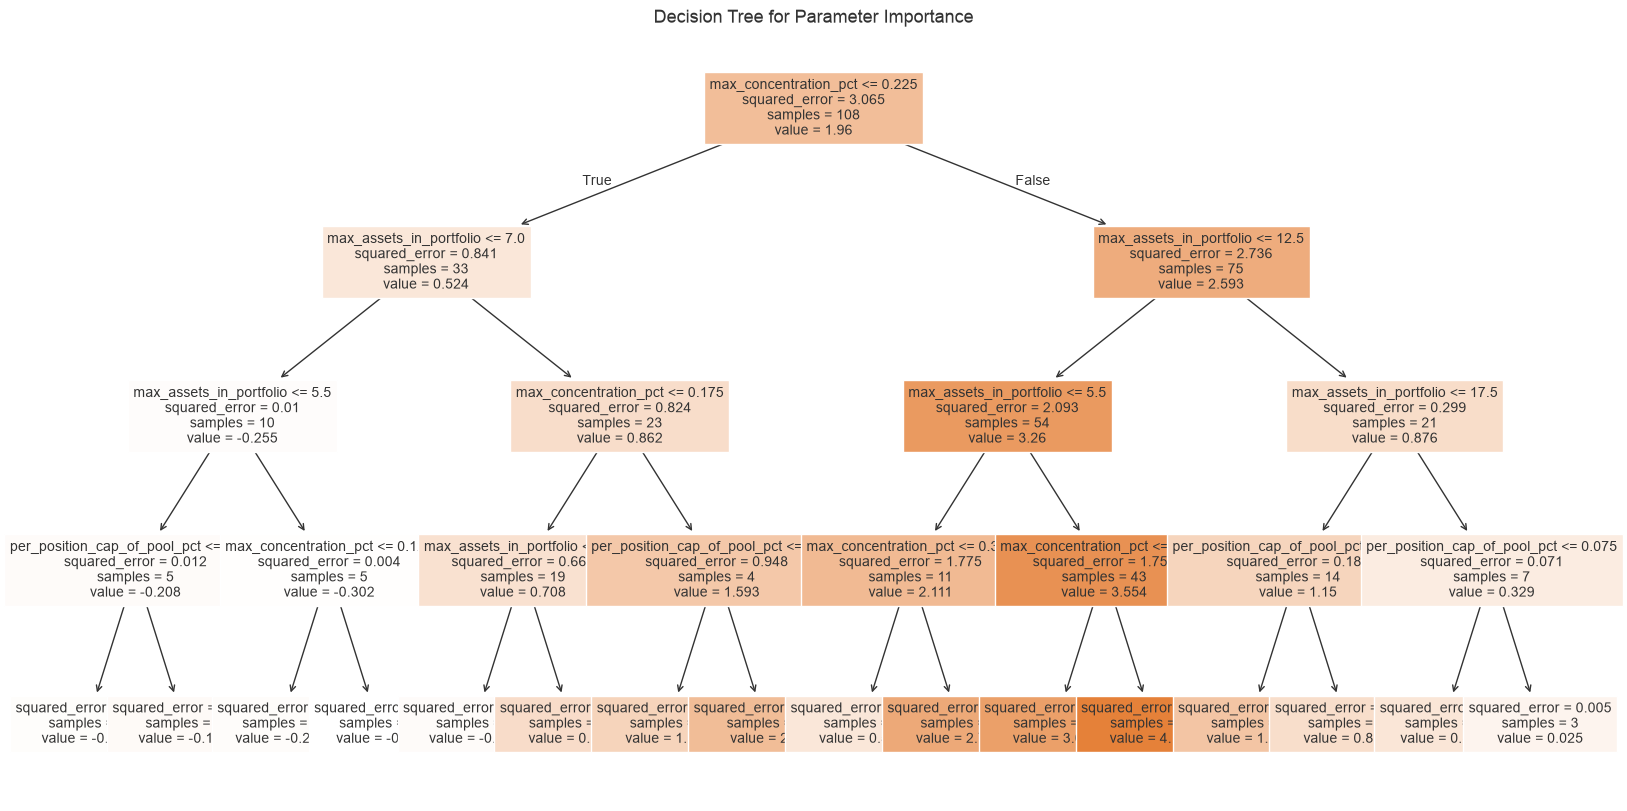

In [12]:
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor, plot_tree

parameter_names = list(df.index.names)
parameter_df = df
parameter_df = parameter_df.reset_index()

analysis_metric = "Calmar"
print(f"Analysing {analysis_metric} for parameters: {parameter_names}")

# Prepare data
X = parameter_df[parameter_names]
y = parameter_df[analysis_metric]

# Convert categorical values if needed
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# Train a simple decision tree
tree = DecisionTreeRegressor(max_depth=4)
tree.fit(X, y)

# Plot
plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=X.columns, filled=True, fontsize=10)
plt.title('Decision Tree for Parameter Importance')
plt.show()

## Feature importance analysis

Use a regression model to determine which parameters have the strongest influence.



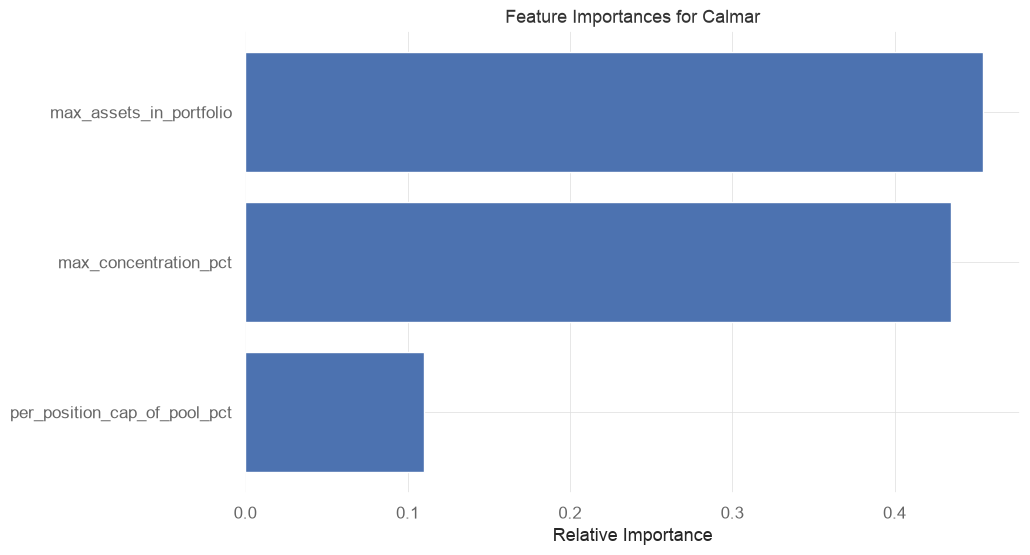

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
X = parameter_df[parameter_names]
y = parameter_df[analysis_metric]

# Convert categorical values to numeric if needed
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# Train a random forest model
model = RandomForestRegressor(n_estimators=100)
model.fit(X, y)

# Plot feature importances
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title(f'Feature Importances for {analysis_metric}')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## Heatmaps for parameter pairs

/var/folders/12/pbc59svn70q_9dfz1kjl3zww0000gn/T/ipykernel_42100/2740836782.py:6: FutureWarning: The provided callable <function mean at 0x10e1175e0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot = df.pivot_table(


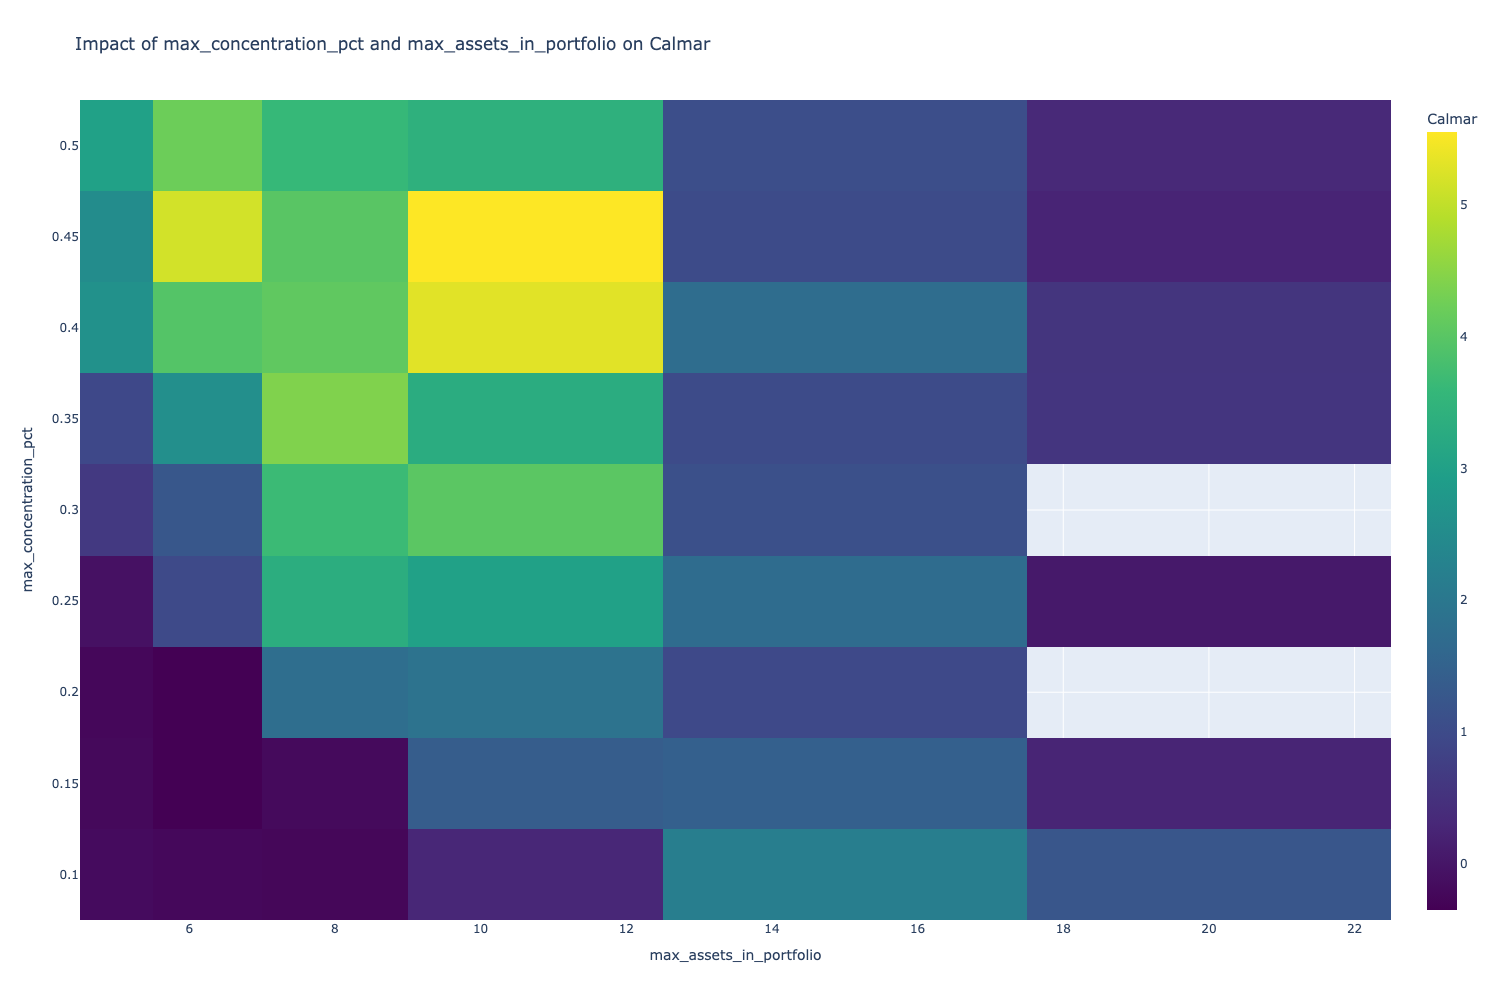

/var/folders/12/pbc59svn70q_9dfz1kjl3zww0000gn/T/ipykernel_42100/2740836782.py:6: FutureWarning: The provided callable <function mean at 0x10e1175e0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot = df.pivot_table(


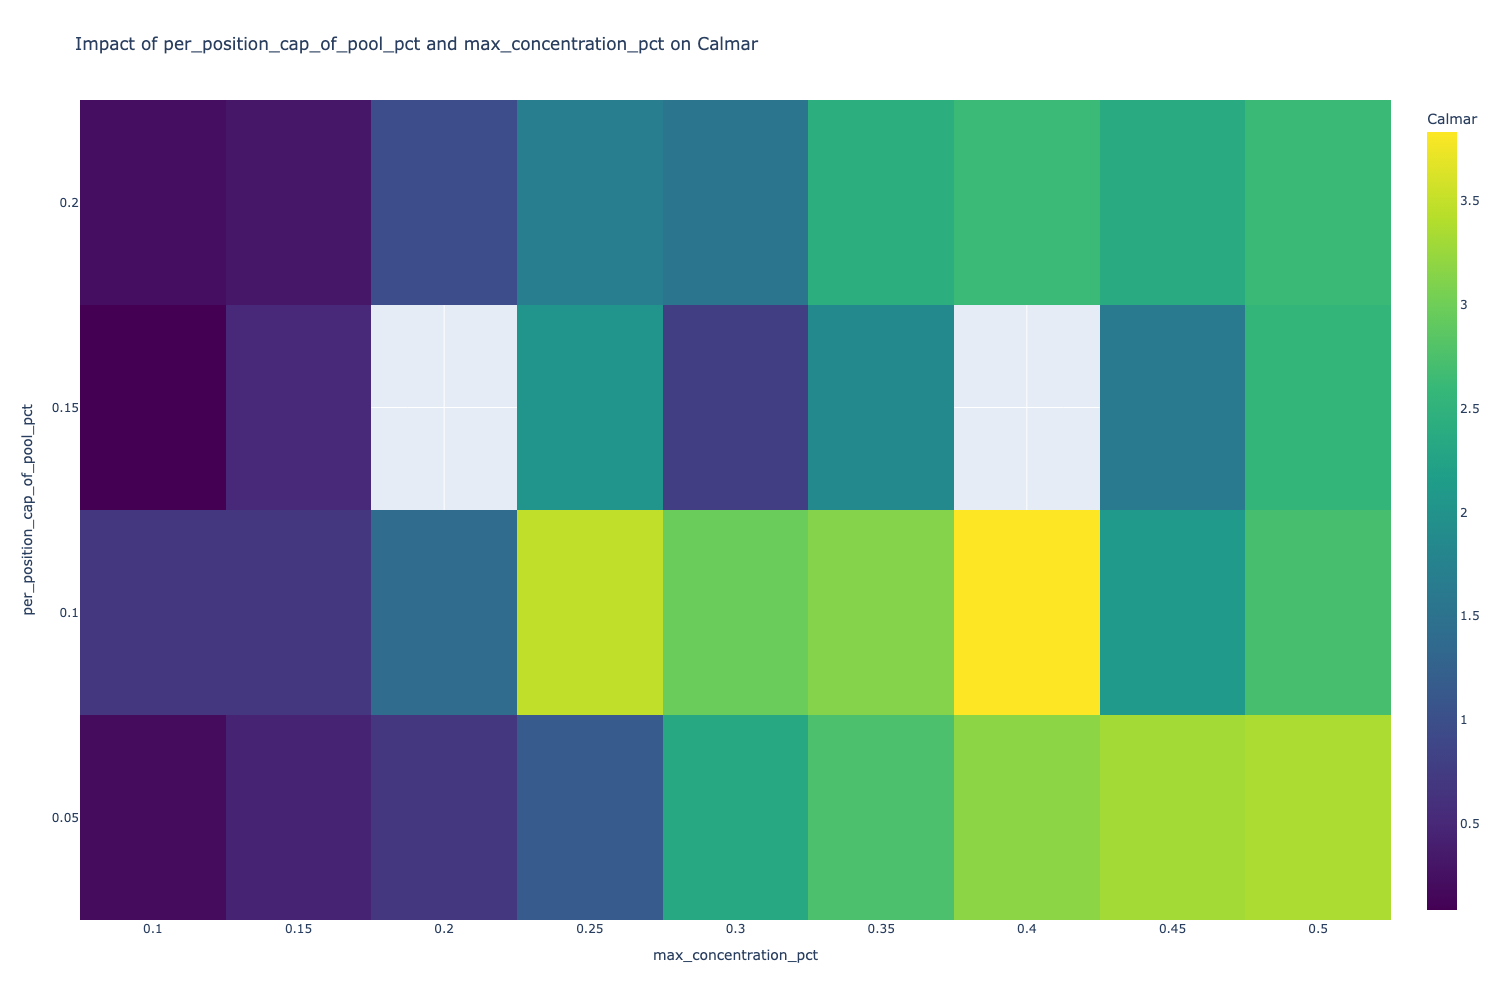

In [14]:
import plotly.graph_objects as go
import numpy as np

def create_heatmap(df, param1, param2, metric):
    # Create pivot table
    pivot = df.pivot_table(
        values=metric, 
        index=param1,
        columns=param2,
        aggfunc=np.mean
    )
    
    fig = go.Figure(data=go.Heatmap(
        z=pivot.values,
        x=pivot.columns,
        y=pivot.index,
        colorscale='Viridis',
        colorbar=dict(title=metric)
    ))
    
    fig.update_layout(
        title=f'Impact of {param1} and {param2} on {metric}',
        xaxis_title=param2,
        yaxis_title=param1
    )
    
    return fig

# Example parameter pairs to analyze
param_pairs = []
for i in range(1, len(parameter_names), 1):
    param_pairs.append((parameter_names[i], parameter_names[i-1]))

for param1, param2 in param_pairs:
    fig = create_heatmap(parameter_df, param1, param2, metric=analysis_metric)
    fig.show()

## Cluster analysis

cluster      CAGR                              Sharpe                Max DD  \
               mean       min       max count      mean   min   max      mean   
0       0  0.103957 -0.079836  0.300147    31  0.680645 -0.28  1.71 -0.128387   
1       1  0.046381 -0.004192  0.087484    18  0.654444 -0.03  1.15 -0.050556   
2       2  0.256752  0.091707  0.466452    32  1.478438  0.69  1.95 -0.078750   
3       3  0.052435  0.002810  0.146885    14  0.665000  0.08  1.51 -0.055714   
4       4  0.093004 -0.079654  0.367673    13  0.631538 -0.15  1.49 -0.121538   

               
    min   max  
0 -0.28 -0.04  
1 -0.06 -0.05  
2 -0.18 -0.04  
3 -0.06 -0.05  
4 -0.27 -0.04

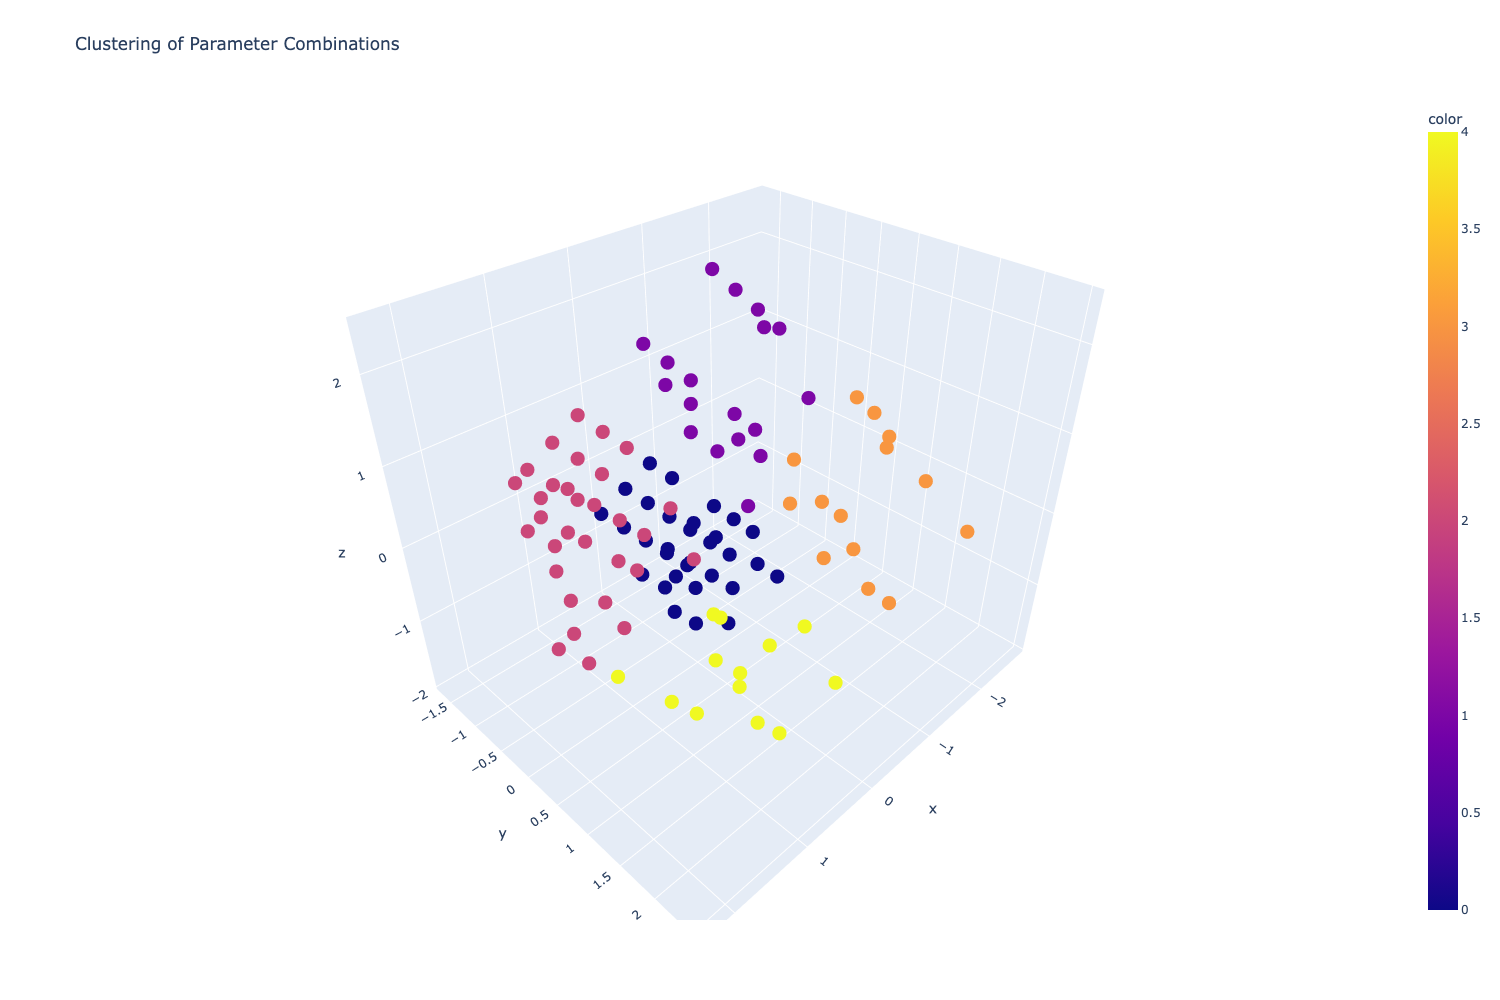

In [15]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import plotly.express as px

# Select features for clustering
features = parameter_names
X = parameter_df[features]

# Convert categorical values to numeric
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-means clustering (determine optimal k separately)
kmeans = KMeans(n_clusters=5, random_state=42)
parameter_df['cluster'] = kmeans.fit_predict(X_scaled)

# Analyze performance by cluster
cluster_perf = parameter_df.groupby('cluster').agg({
    'CAGR': ['mean', 'min', 'max', 'count'],
    'Sharpe': ['mean', 'min', 'max'],
    'Max DD': ['mean', 'min', 'max']
}).reset_index()

display(cluster_perf)

# Visualize clusters in 3D space (using first 3 PCA components)
from sklearn.decomposition import PCA

try:
    pca = PCA(n_components=3)
    components = pca.fit_transform(X_scaled)

    fig = px.scatter_3d(
        x=components[:, 0],
        y=components[:, 1],
        z=components[:, 2],
        color=parameter_df['cluster'],
        hover_data={'Sharpe': parameter_df['Sharpe'], 'CAGR': parameter_df['CAGR']},
        title='Clustering of Parameter Combinations'
    )
    fig.show()
except ValueError as e:
    print(f"Error in PCA: {e}")
    print("PCA failed, possibly due to too few features or singular matrix.")
    # Handle the error as needed

## Parallel coordinates plot

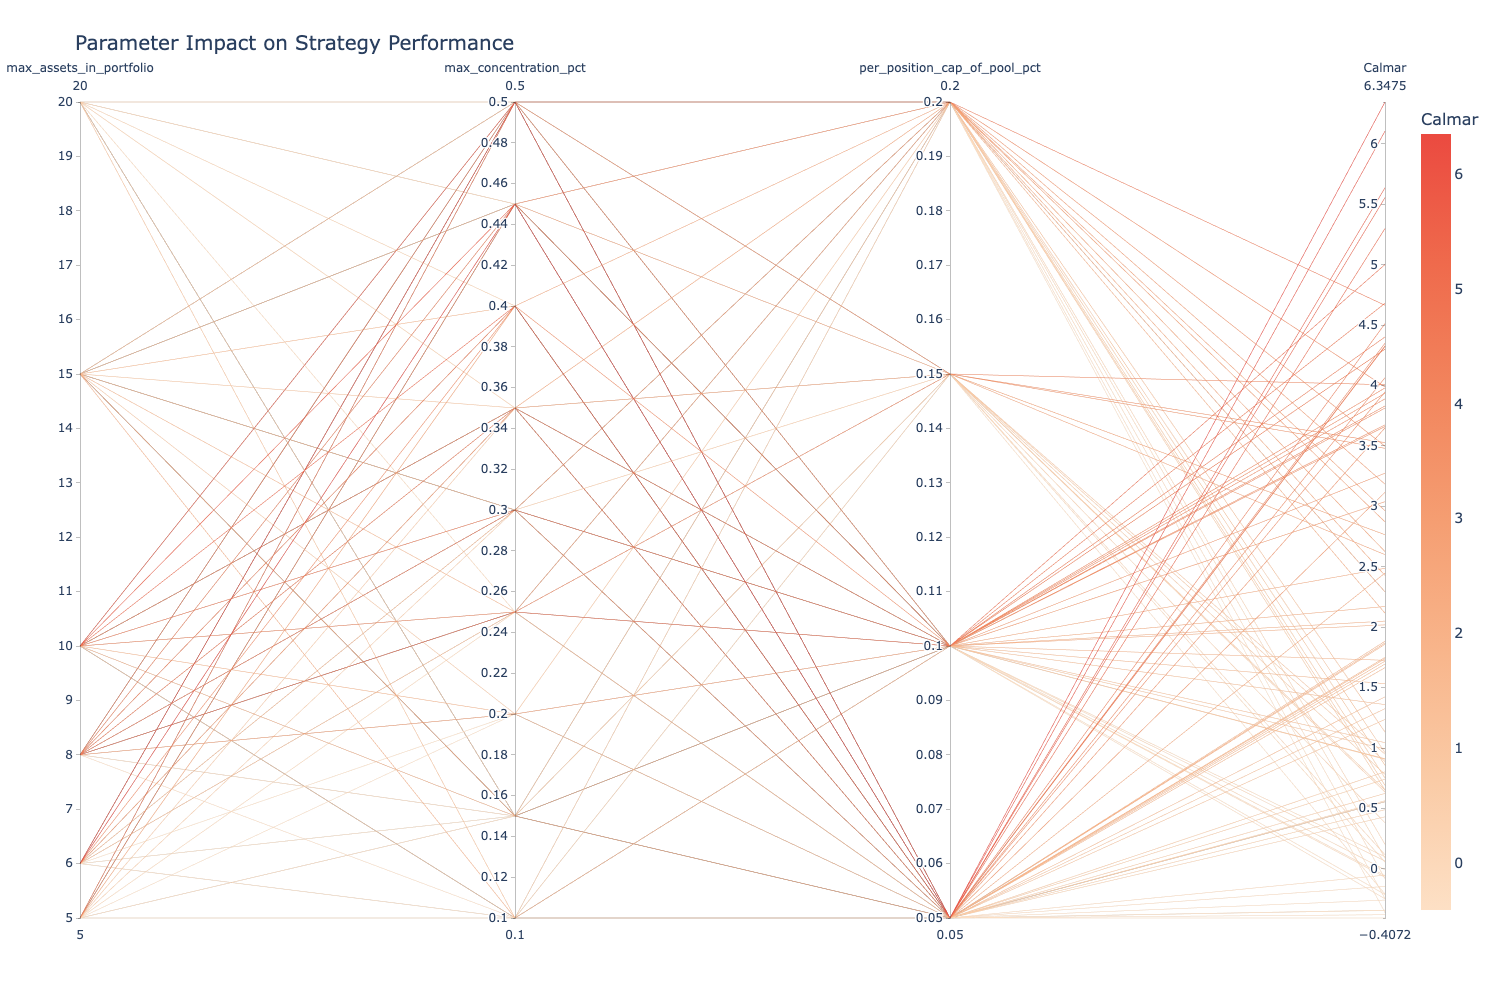

In [16]:
import plotly.express as px

# Extract top results (e.g., top 50)
top_results = parameter_df.head(50)

dimensions = parameter_names + [analysis_metric]

# Create parallel coordinates plot
fig = px.parallel_coordinates(
    parameter_df,
    dimensions=dimensions,
    color=analysis_metric,
    color_continuous_scale=px.colors.sequential.Peach,
    title='Parameter Impact on Strategy Performance'
)


# Increase font size for axis titles, tick labels, and title
fig.update_layout(
    font=dict(size=14),  # Base font size for the whole figure
    title=dict(
        text='Parameter Impact on Strategy Performance',
        font=dict(size=20)  # Title font size
    ),
    coloraxis_colorbar=dict(
        title=dict(
            text=analysis_metric,
            font=dict(size=16)
        ),
        tickfont=dict(size=14)
    )
)

# Parallel coordinates chart: Line width not supported
# https://github.com/plotly/plotly.js/issues/2573

fig.show()

# The best candidate equity curve

The best result found for <function optimise_calmar at 0x12be09e80> was <GridSearchResult
  #76, max_assets_in_portfolio=6, max_concentration_pct=0.45, per_position_cap_of_pool_pct=0.05
  CAGR: 38.00%, Sharpe: 1.84, Sortino: 2.88, Max drawdown:-6.00%
>


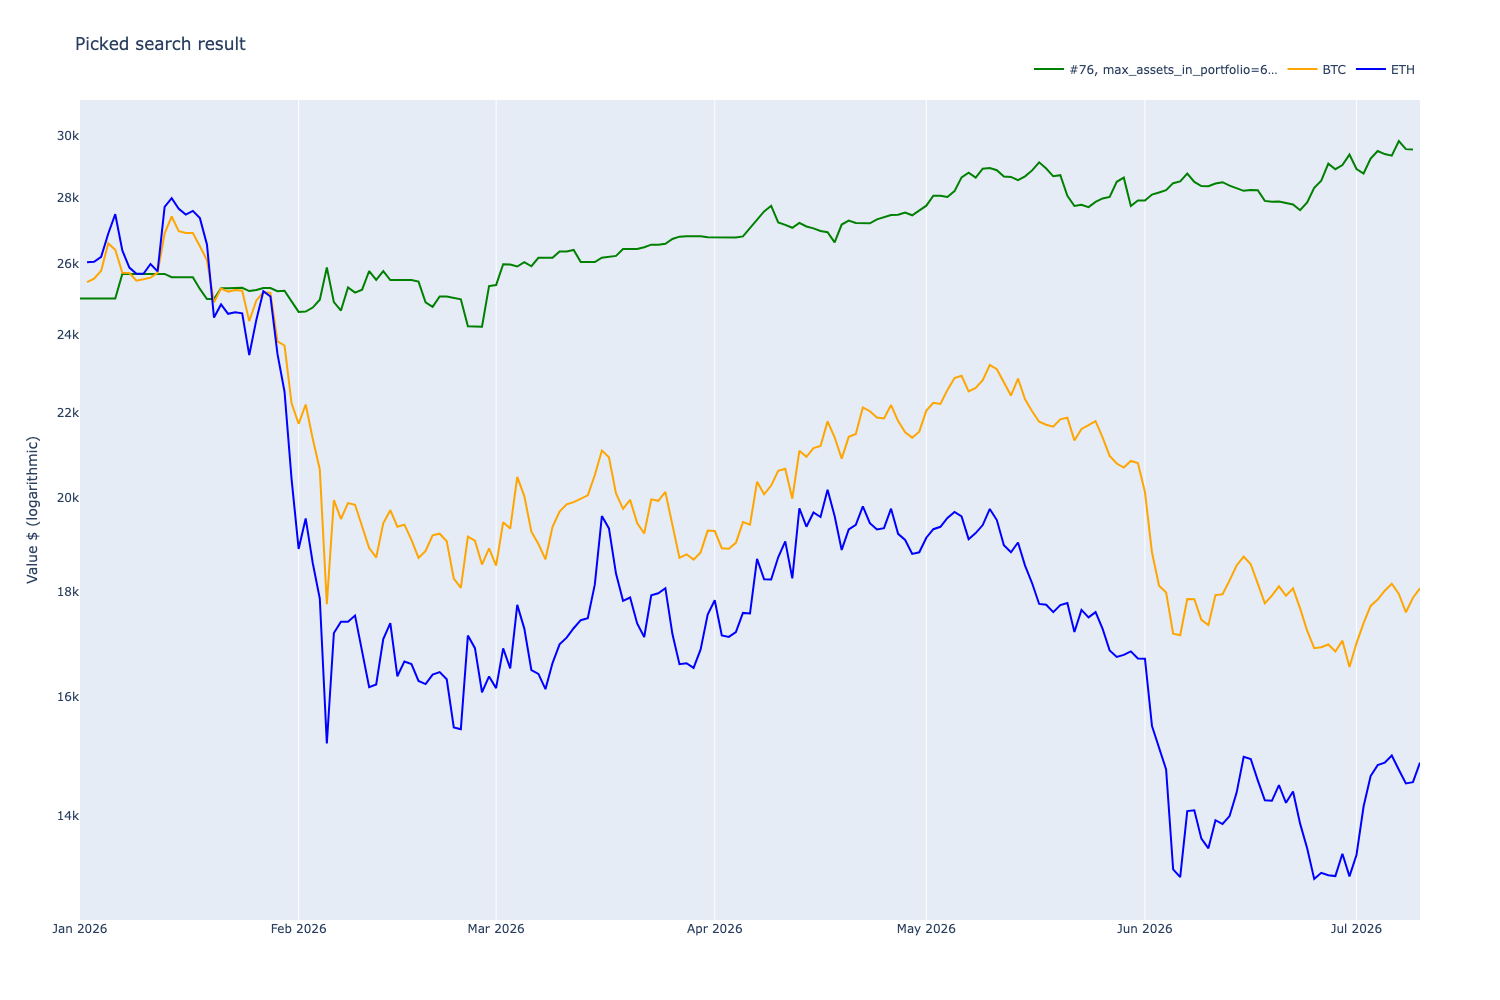

In [17]:
from tradeexecutor.visual.grid_search import visualise_single_grid_search_result_benchmark

# GridSearchResult instance that gave the best performance
best_pick = next(result.result for result in optimiser_result.results if not result.filtered)
state = best_pick.hydrate_state()

print(f"The best result found for {search_func} was {best_pick}")

fig = visualise_single_grid_search_result_benchmark(
    best_pick, 
    strategy_universe, 
    initial_cash=Parameters.initial_cash,
    log_y=True,
)
fig.show()

# Portfolio performance (best pick)

- Compare buy and hold against our best performance

In [18]:
from tradeexecutor.analysis.multi_asset_benchmark import compare_strategy_backtest_to_multiple_assets

returns = best_pick.returns

df = compare_strategy_backtest_to_multiple_assets(
    state=state,
    strategy_universe=strategy_universe,
    returns=returns,
    display=True,
    asset_count=3,
)
display(df)

,Strategy,BTC,ETH
Start Period,2026-01-01,2026-01-01,2026-01-01
End Period,2026-07-09,2026-07-09,2026-07-09
Risk-Free Rate,0.0%,0.0%,0.0%
Time in Market,92.0%,97.0%,97.0%
Cumulative Return,18.19%,-32.27%,-47.07%
CAGR﹪,38.09%,-52.88%,-70.73%
Sharpe,1.84,-1.31,-1.57
Prob. Sharpe Ratio,90.92%,17.33%,13.04%
Smart Sharpe,1.76,-1.25,-1.5
Sortino,2.88,-1.75,-2.11


# Trade summary (best pick)

- Show statistics about the made trades

In [19]:
summary = best_pick.summary
display(summary.to_dataframe())

,0
Trading period length,189 days 0 hours
Trading start,None
Trading end,None
Return %,18.19%
Annualised return %,35.12%
Cash at start,"$25,000.00"
Value at end,"$29,546.73"
Time in market,0.00%
Time in market volatile,0.00%
Trade volume,"$786,440.51"


# Trading pair performance breakdown

- Show breakdown of different pairs on the best result

In [20]:
from tradeexecutor.analysis.multipair import analyse_multipair
from tradeexecutor.analysis.multipair import format_multipair_summary

multipair_summary = analyse_multipair(state)
display(format_multipair_summary(multipair_summary))

,Trading pair,Positions,Trades,Total return %,Total PnL USD,Best,Worst,Avg,Median,Volume,Wins,Losses,Take profits,Stop losses,Trailing stop losses,Volatility
1,Realist Capital,4,109,32.35%,"2,273.41",29.27%,0.38%,8.09%,1.35%,"79,427.57",4,0,0,0,0,12.24%
3,Scared Money,8,76,28.50%,"1,075.92",20.57%,-23.06%,3.56%,5.01%,"38,242.29",5,3,0,0,0,12.67%
23,HyperProfit {PRO},2,6,24.76%,112.21,23.66%,1.10%,12.38%,12.38%,"2,149.87",2,0,0,0,0,11.28%
0,Goon Edging,6,68,11.88%,928.84,9.61%,-11.00%,1.98%,5.07%,"55,800.22",4,2,0,0,0,6.99%
6,Growi HF,1,4,6.22%,382.06,6.22%,6.22%,6.22%,6.22%,"12,667.37",1,0,0,0,0,0.00%
17,Gucky_1coin_1dot5x,1,54,4.12%,294.50,4.12%,4.12%,4.12%,4.12%,"14,589.37",1,0,0,0,0,0.00%
4,pmalt,4,126,3.75%,"1,623.19",4.64%,-2.71%,0.94%,0.91%,"96,297.88",3,1,0,0,0,2.60%
25,OIB,2,6,2.88%,98.47,2.95%,-0.07%,1.44%,1.44%,"13,974.28",1,1,0,0,0,1.51%
7,Mahamor,1,2,1.35%,15.75,1.35%,1.35%,1.35%,1.35%,"2,354.34",1,0,0,0,0,0.00%
18,Gucky_2coin_1dot75x,1,17,1.27%,15.13,1.27%,1.27%,1.27%,1.27%,"2,406.07",1,0,0,0,0,0.00%


# Best positions

- Find positions that made most profit for the leading backtest

In [21]:
profit_by_position = [(p.get_realised_profit_usd(), p) for p in state.portfolio.get_all_positions()]
profit_by_position.sort(key=lambda t: t[0] or -999_999_999, reverse=True)

data = []

for profit, p in profit_by_position[0:5]:
    data.append({
        "Profit USD": profit,
        "Pair": p.pair.get_ticker(),
        "Position id": p.position_id,
        "Opened": p.opened_at,
        "Closed": p.closed_at,
        "Duration": p.closed_at - p.opened_at if p.closed_at else "(still open)",
        "Open price": p.get_opening_price(),
        "Close price": p.get_closing_price(),
        "Trades": p.get_trade_count(),
        "Price gain %": (p.get_closing_price() - p.get_opening_price()) / p.get_opening_price() * 100,
        "Weight at open %": p.get_capital_tied_at_open_pct() * 100,
    })

df = pd.DataFrame(data)
display(df)

,Profit USD,Pair,Position id,Opened,Closed,Duration,Open price,Close price,Trades,Price gain %,Weight at open %
0,1694.705743,pmalt-USDC,5,2026-01-01,2026-05-21,"140 days, 0:00:00",2.206690,2.408450,109,9.143095,8.846764
1,874.461043,Realist Ca-USDC,71,2026-06-23,NaT,(still open),4.544133,8.042990,16,76.997250,9.672365
2,732.540952,Scared Mon-USDC,38,2026-04-26,2026-05-17,"21 days, 0:00:00",0.000026,0.000031,22,19.259475,4.946892
3,538.721219,Citadel-USDC,13,2026-01-28,2026-04-05,"67 days, 0:00:00",5.687629,6.064484,63,6.625873,6.829364
4,507.336017,Goon Edgin-USDC,15,2026-02-01,2026-02-20,"19 days, 0:00:00",1.524321,1.748629,19,14.715234,15.132085


# Rolling sharpe

- The rolling sharpe ratio of the best pick

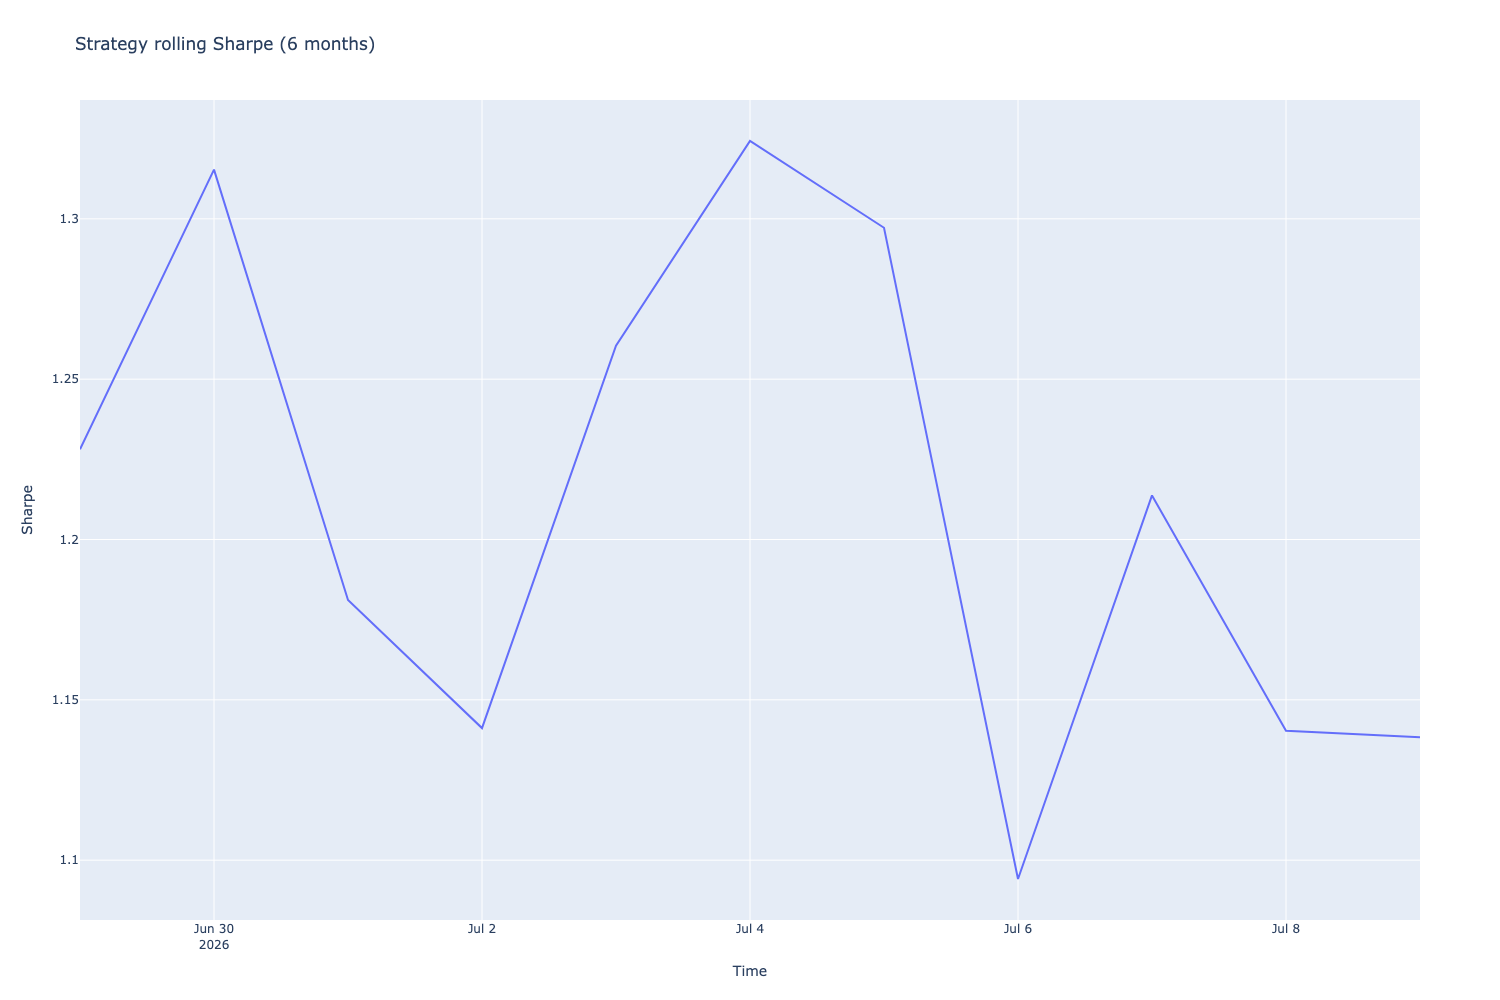

In [22]:
import plotly.express as px

from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.visual.equity_curve import calculate_rolling_sharpe

rolling_sharpe = calculate_rolling_sharpe(
    returns,
    freq="D",
    periods=180,
)

fig = px.line(rolling_sharpe, title='Strategy rolling Sharpe (6 months)')
fig.update_layout(showlegend=False)
fig.update_yaxes(title="Sharpe")
fig.update_xaxes(title="Time")
fig.show()

# Data diagnosics

- Some example code to track down issues with data


In [23]:
# data = [{"Timestamp": s.calculated_at, "Equity": s.net_asset_value} for s in state.stats.portfolio]
# df = pd.DataFrame(data)
# df = df.set_index("Timestamp")

# with pd.option_context('display.min_rows', 50, "display.max_rows", 50):
#     display(df)

In [24]:
# for t in state.portfolio.get_all_trades():
#     if t.executed_at.date() == datetime.date(2023, 12, 29):
#         print(t, t.pair, t.get_value())

In [25]:
# import plotly.graph_objects as go

# pair_desc = (ChainId.ethereum, "uniswap-v3", "WBTC", "USDC", 0.0005)
# pair = strategy_universe.get_pair_by_human_description(pair_desc)
# df = strategy_universe.data_universe.candles.get_candles_by_pair(pair.internal_id)


# fig = go.Figure(data=go.Ohlc(x=df.timestamp,
#                     open=df.open,
#                     high=df.high,
#                     low=df.low,
#                     close=df.close))
# fig.show()

# with pd.option_context('display.min_rows', 5000, "display.max_rows", 5000, 'display.float_format', lambda x: f'{x:.6f}'):
#     display(df)